# Unidad 6 · Análisis de sentimiento y tendencias en redes sociales — Análisis de redes e integración de LLMs

Asignatura: Búsqueda y Análisis de la Información.    
Alumno: Rodrigo de Siqueira-Lima Pérez-Moreno

## Descripción

Esta entrega es la continuación de las prácticas de las Unidades 2 y 4. Sobre la clase `DataExtractor` ya existente, esta unidad añade:

- **Análisis de redes** con NetworkX: grafo de menciones, métricas de centralidad y detección de comunidades (Louvain).
- **Integración con un LLM en local** (`google/gemma-4-E2B-it` vía `transformers`): se genera un prompt con los insights de la red y el modelo devuelve un análisis interpretativo.
- **App Gradio** para chatear con el modelo sobre la red.

Se mantiene todo lo de la U4 (extracción por API, limpieza, hashtags, keywords, tópicos LDA, sentimiento y parsing), y toda la lógica sigue centralizada en `DataExtractor`.

### Datos

La fuente principal del análisis es la API. Como respaldo dejo el dataset de Bitcoin Tweets de Kaggle (`data/bronze/Bitcoin_tweets_dataset_2.csv`) por si la cuota de la API se agotara.

Toda la lógica vive dentro de la clase `DataExtractor`.

## Librerías

In [1]:
import os
import re
import csv
import json
import requests
import polars as pl
import matplotlib.pyplot as plt
import nltk
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv
from gensim import corpora
from gensim.models import LdaModel, Phrases
from gensim.models.phrases import Phraser
from gensim.models.coherencemodel import CoherenceModel
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import networkx as nx

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)


True

## Clase `DataExtractor`

In [2]:
class DataExtractor:
    extra_stopwords = {
        'rt', 'amp', 'via', 'u', 'im', 'dont', 'cant', 'gonna', 'wanna', 'lol',
        'ur', 'w', 's', 'get', 'got', 'one', 'like', 'go', 'going', 'see', 'use',
        'new', 'day', 'time', 'year', 'week', 'way', 'even', 'good', 'know',
        'still', 'back', 'also',
    }
    crypto_core = {'bitcoin', 'btc', 'crypto', 'cryptocurrency'}

    def __init__(self, source=None, data_root='data'):
        self.source = source
        self.data   = None
        self.data_root  = Path(data_root)
        self.bronze_dir = self.data_root / 'bronze'
        self.silver_dir = self.data_root / 'silver'
        self.gold_dir   = self.data_root / 'gold'
        for d in (self.bronze_dir, self.silver_dir, self.gold_dir):
            d.mkdir(parents=True, exist_ok=True)
        self.next_cursor = None
        nltk_sw = set(nltk.corpus.stopwords.words('english'))
        self.stopwords_keywords = nltk_sw | self.extra_stopwords | self.crypto_core
        self.stopwords_lda      = nltk_sw | self.extra_stopwords

    def load_data_api(self, query, max_results=100, output_file=None):
        load_dotenv()
        api_key = os.getenv('RAPIDAPI_KEY')
        if not api_key:
            raise ValueError('Falta RAPIDAPI_KEY en .env')
        if output_file is None:
            output_file = str(self.bronze_dir / 'tweets_from_api.csv')

        url = 'https://twitter-api45.p.rapidapi.com/search.php'
        headers = {'x-rapidapi-host': 'twitter-api45.p.rapidapi.com', 'x-rapidapi-key': api_key}

        tweets = []
        while len(tweets) < max_results:
            params = {'query': query, 'search_type': 'Top'}
            if self.next_cursor:
                params['cursor'] = self.next_cursor
            resp = requests.get(url, headers=headers, params=params, timeout=15)
            try:
                resp.raise_for_status()
                data = resp.json()
            except (requests.HTTPError, ValueError) as e:
                print(f'  Aviso: respuesta no valida ({e}). Paro la descarga.')
                break
            batch = data.get('timeline', [])
            if not batch:
                break
            tweets.extend(batch)
            self.next_cursor = data.get('next_cursor')
            if not self.next_cursor:
                break

        tweets = tweets[:max_results]
        if not tweets:
            print('La API no devolvio tweets en esta llamada.')
            return self.data

        rows = []
        for t in tweets:
            user_info = t.get('user_info', {})
            raw_date  = t.get('created_at', '')
            try:
                iso_date = datetime.strptime(raw_date, '%a %b %d %H:%M:%S %z %Y').strftime('%Y-%m-%d %H:%M:%S')
            except (ValueError, TypeError):
                iso_date = raw_date
            rows.append({
                'user_name':      t.get('screen_name', ''),
                'date':           iso_date,
                'text':           t.get('text', ''),
                'tweet_id':       str(t.get('tweet_id', '')),
                'user_followers': user_info.get('followers_count'),
                'is_retweet':     str(t.get('text', '')).startswith('RT '),
            })

        # Append con csv stdlib (polars no soporta modo append)
        file_exists = Path(output_file).exists()
        with open(output_file, 'a', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=rows[0].keys())
            if not file_exists:
                writer.writeheader()
            writer.writerows(rows)

        full = pl.read_csv(output_file, infer_schema_length=None)
        self.data   = full
        self.source = output_file
        print(f'{len(rows)} nuevos. Total acumulado en "{output_file}": {len(full)}')
        return full

    def load_data(self):
        if self.source is None:
            raise ValueError('No hay archivo fuente.')
        if self.source.endswith('.csv'):
            self.data = (
                pl.scan_csv(self.source, encoding='utf8', infer_schema_length=None)
                .collect()
            )
        elif self.source.endswith('.json'):
            self.data = pl.read_ndjson(self.source)
        else:
            raise ValueError('Formato no soportado. Usa CSV o JSON.')
        return self.data

    def clean_text(self, text):
        if not isinstance(text, str):
            return ''
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
        text = re.sub(r'@\w+', ' ', text)
        text = re.sub(r'[^0-9a-z#\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def extract_hashtags(self, text):
        if not isinstance(text, str):
            return []
        return re.findall(r'#\w+', text)

    def extract_keywords(self, text, min_length=3):
        if not isinstance(text, str) or not text.strip():
            return []
        return [
            w for w in text.split()
            if len(w) >= min_length
            and w not in self.stopwords_keywords
            and not w.startswith('#')
            and not w.isdigit()
        ]

    def analytics_keywords(self, top_n=30):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        return (
            df.with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean')
            ).with_columns(
                pl.col('clean').map_elements(self.extract_keywords, return_dtype=pl.List(pl.String)).alias('keywords')
            ).explode('keywords')
            .filter(pl.col('keywords').is_not_null())
            .filter(pl.col('keywords').str.strip_chars() != '')
            .group_by('keywords')
            .agg(pl.len().alias('frequency'))
            .rename({'keywords': 'keyword'})
            .sort('frequency', descending=True)
            .head(top_n)
        )

    def model_topics(self, num_topics=5, passes=10, sample_size=None,
                     use_bigrams=True, compute_coherence=True):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        if 'clean_text' not in df.columns:
            df = df.with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean_text')
            )
        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, seed=42)

        def filter_tokens(tokens):
            return [
                w for w in tokens
                if w not in self.stopwords_lda
                and len(w) > 2
                and not w.isdigit()
                and not w.startswith('http')
            ]

        texts  = df['clean_text'].drop_nulls().to_list()
        tokens = [filter_tokens(t.split()) for t in texts]
        tokens = [t for t in tokens if t]

        if use_bigrams:
            bigram_model   = Phrases(tokens, min_count=10, threshold=20)
            bigram_phraser = Phraser(bigram_model)
            tokens = [bigram_phraser[t] for t in tokens]

        dictionary = corpora.Dictionary(tokens)
        dictionary.filter_extremes(no_below=5, no_above=0.5)
        corpus = [dictionary.doc2bow(doc) for doc in tokens]

        lda = LdaModel(corpus, num_topics=num_topics, id2word=dictionary,
                       passes=passes, random_state=42)

        topics = []
        for topic_id in range(num_topics):
            words = [w for w, _ in lda.show_topic(topic_id, topn=10)]
            topics.append(words)

        coherence = None
        if compute_coherence:
            try:
                coherence = CoherenceModel(
                    model=lda, texts=tokens, dictionary=dictionary, coherence='c_v'
                ).get_coherence()
            except Exception as e:
                print(f'No se pudo calcular la coherencia: {e}')

        out = {f'topic_{i}': words for i, words in enumerate(topics)}
        out['_coherence_c_v'] = coherence
        (self.gold_dir / 'topics_lda.json').write_text(
            json.dumps(out, indent=2, ensure_ascii=False)
        )
        return {'topics': topics, 'coherence': coherence}

    def analyze_sentiment(self, method='textblob', sample_size=None):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        text_col = 'clean_text' if 'clean_text' in df.columns else 'text'
        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, seed=42)

        if method == 'textblob':
            texts = df[text_col].fill_null('').to_list()
            sents = [TextBlob(t).sentiment for t in texts]
            df = df.with_columns([
                pl.Series('sentiment_polarity',    [s.polarity     for s in sents]),
                pl.Series('sentiment_subjectivity', [s.subjectivity for s in sents]),
            ])
        elif method == 'vader':
            analyzer = SentimentIntensityAnalyzer()
            raw_col  = 'text' if 'text' in df.columns else text_col
            texts    = df[raw_col].fill_null('').to_list()
            scores   = [analyzer.polarity_scores(t) for t in texts]
            df = df.with_columns([
                pl.Series('sentiment_polarity',    [s['compound']   for s in scores]),
                pl.Series('sentiment_subjectivity', [1.0 - s['neu'] for s in scores]),
            ])
        else:
            raise ValueError(f"Metodo '{method}' no soportado. Usa 'textblob' o 'vader'.")

        self.data = df
        df.write_parquet(self.gold_dir / f'sentiment_scored_{method}.parquet')
        return self.data

    def parse_and_summarize(self, summary_ratio=0.3):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        text_col    = 'clean_text' if 'clean_text' in df.columns else 'text'
        corpus_text = ' '.join(df[text_col].drop_nulls().cast(pl.String).to_list())

        sentences = nltk.sent_tokenize(corpus_text)
        if not sentences:
            return ''

        word_freq = {}
        for sentence in sentences:
            for word in sentence.lower().split():
                word = re.sub(r'[^a-z0-9]', '', word)
                if word and word not in self.stopwords_keywords:
                    word_freq[word] = word_freq.get(word, 0) + 1

        sentence_scores = {}
        for i, sentence in enumerate(sentences):
            sentence_scores[i] = sum(
                word_freq.get(re.sub(r'[^a-z0-9]', '', w.lower()), 0)
                for w in sentence.split()
            )

        n_select    = max(1, int(len(sentences) * summary_ratio))
        top_indices = sorted(
            sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:n_select]
        )
        summary = ' '.join(sentences[i] for i in top_indices)
        (self.gold_dir / 'summary.txt').write_text(summary, encoding='utf-8')
        return summary

    def analytics_hashtags_extended(self):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df_pl = self.data
        if 'text' not in df_pl.columns:
            raise KeyError("No hay columna 'text' en el dataset.")

        df = (
            df_pl
            .with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean_text')
            ).with_columns(
                pl.col('clean_text').map_elements(self.extract_hashtags, return_dtype=pl.List(pl.String)).alias('hashtags_ext')
            ).with_columns(
                pl.col('date').cast(pl.String)
                .str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
                .dt.date().alias('date')
            )
        )

        df_exp = (
            df.explode('hashtags_ext')
            .filter(pl.col('hashtags_ext').is_not_null())
            .filter(pl.col('hashtags_ext').str.strip_chars() != '')
        )

        overall = (
            df_exp.group_by('hashtags_ext')
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort('frequency', descending=True)
        )
        by_user = (
            df_exp.group_by(['user_name', 'hashtags_ext'])
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort('frequency', descending=True)
        )
        by_date = (
            df_exp.group_by(['date', 'hashtags_ext'])
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort(['date', 'frequency'], descending=[False, True])
        )

        overall.write_csv(self.gold_dir / 'hashtags_overall.csv')
        by_user.write_csv(self.gold_dir / 'hashtags_by_user.csv')
        by_date.write_csv(self.gold_dir / 'hashtags_timeline.csv')
        return {'overall': overall, 'by_user': by_user, 'by_date': by_date}

    def generate_hashtag_wordcloud(self, overall_df=None, max_words=100, figsize=(10, 6)):
        if overall_df is None:
            overall_df = self.analytics_hashtags_extended()['overall']
        if overall_df.is_empty():
            print('No hay hashtags para generar la wordcloud.')
            return
        freq_dict = dict(zip(overall_df['hashtag'].to_list(), overall_df['frequency'].to_list()))
        wc = WordCloud(width=1200, height=600, background_color='white',
                       max_words=max_words, colormap='plasma')
        wc.generate_from_frequencies(freq_dict)
        plt.figure(figsize=figsize)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Hashtags mas frecuentes en tweets de Bitcoin', fontsize=14)
        plt.tight_layout()
        plt.show()


    # --- ANÁLISIS DE REDES CON NETWORKX (Unidad 6) ---
    def extract_mentions(self, text):
        if not isinstance(text, str):
            return []
        return [m.lower() for m in re.findall(r'@(\w+)', text)]

    def build_interaction_graph(self):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        if 'mentions' not in df.columns:
            df = df.with_columns(
                pl.col('text').map_elements(self.extract_mentions, return_dtype=pl.List(pl.String)).alias('mentions')
            )
        G = nx.DiGraph()
        for autor, menciones in zip(df['user_name'].to_list(), df['mentions'].to_list()):
            if not autor or not menciones:
                continue
            autor = autor.lower()
            for mencionado in menciones:
                if mencionado == autor:
                    continue
                if G.has_edge(autor, mencionado):
                    G[autor][mencionado]['weight'] += 1
                else:
                    G.add_edge(autor, mencionado, weight=1)
        return G

    def analyze_network(self, G, top_n=3, draw=True):
        if G.number_of_nodes() == 0:
            print('El grafo está vacío, no hay menciones que analizar.')
            return {}
        deg_cent = nx.degree_centrality(G)
        bet_cent = nx.betweenness_centrality(G)
        comunidades = nx.community.louvain_communities(G.to_undirected(), seed=42)
        comunidad_de = {}
        for i, grupo in enumerate(comunidades):
            for nodo in grupo:
                comunidad_de[nodo] = i

        top_centralidad = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:top_n]

        print(f'Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}')
        print(f'Comunidades detectadas (Louvain): {len(comunidades)}')
        print(f'Top {top_n} usuarios por centralidad de grado:')
        for nodo, valor in top_centralidad:
            print(f'  @{nodo}: centralidad={valor:.3f}, intermediación={bet_cent[nodo]:.3f}, grado={G.degree(nodo)}')

        metricas = {
            'num_nodos': G.number_of_nodes(),
            'num_aristas': G.number_of_edges(),
            'num_comunidades': len(comunidades),
            'top_centralidad': [
                {'usuario': n, 'centralidad': round(deg_cent[n], 4),
                 'intermediacion': round(bet_cent[n], 4)}
                for n, _ in top_centralidad
            ],
        }
        (self.gold_dir / 'network_metrics.json').write_text(
            json.dumps(metricas, indent=2, ensure_ascii=False)
        )

        if draw:
            plt.figure(figsize=(12, 9))
            pos = nx.spring_layout(G, k=0.3, seed=42)
            max_cent = max(deg_cent.values())
            colores = [comunidad_de.get(n, 0) for n in G.nodes()]
            tamanos = [800 * deg_cent[n] / max_cent + 15 for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=tamanos, cmap='tab20', alpha=0.85)
            nx.draw_networkx_edges(G, pos, alpha=0.15, arrowsize=5)
            etiquetas = {n: f'@{n}' for n, _ in top_centralidad}
            nx.draw_networkx_labels(G, pos, labels=etiquetas, font_size=10, font_weight='bold')
            plt.title('Grafo de interacciones (menciones) en tweets de cripto')
            plt.axis('off')
            plt.tight_layout()
            plt.savefig(self.gold_dir / 'network_graph.png', dpi=120)
            plt.show()
        return metricas

    # --- LLM EN LOCAL (Unidad 6) ---
    def generate_prompt_from_network(self, G, hashtag_top=None):
        metricas = self.analyze_network(G, draw=False)
        if not metricas:
            return ''
        if hashtag_top is None:
            overall = self.analytics_hashtags_extended()['overall']
            hashtag_top = overall['hashtag'][0] if not overall.is_empty() else 'N/A'
        top = ', '.join(f"@{u['usuario']}" for u in metricas['top_centralidad'])
        prompt = (
            'Eres un analista de redes sociales. A partir de estos datos de una red de '
            'menciones en tweets sobre criptomonedas, explica posibles razones de las '
            'tendencias observadas.\n\n'
            f"- Usuarios más influyentes (por centralidad): {top}\n"
            f"- Hashtag más frecuente: {hashtag_top}\n"
            f"- Comunidades detectadas: {metricas['num_comunidades']}\n"
            f"- Tamaño de la red: {metricas['num_nodos']} usuarios y {metricas['num_aristas']} interacciones.\n\n"
            'Responde en español de forma concisa y directa, en 2-3 párrafos como máximo; no te extiendas más de lo necesario.'
        )
        return prompt

    def chat_local_llm(self, prompt=None, max_new_tokens=512):
        if getattr(self, '_llm', None) is None:
            from transformers import pipeline
            import torch
            modelo = os.getenv('LLM_MODEL', 'google/gemma-4-E2B-it')
            device = 'mps' if torch.backends.mps.is_available() else 'cpu'
            print(f'Cargando modelo {modelo} en {device} (la primera vez descarga los pesos)...')
            self._llm = pipeline('text-generation', model=modelo, device=device,
                                 dtype=torch.bfloat16, token=os.getenv('HF_TOKEN'))
        if prompt is not None:
            salida = self._llm([{'role': 'user', 'content': prompt}], max_new_tokens=max_new_tokens)
            return salida[0]['generated_text'][-1]['content']
        historial = []
        print("Chat con el modelo (escribe 'salir' para terminar).")
        while True:
            entrada = input('Tú: ')
            if entrada.strip().lower() in ('salir', 'exit', 'quit'):
                break
            historial.append({'role': 'user', 'content': entrada})
            salida = self._llm(historial, max_new_tokens=max_new_tokens)
            respuesta = salida[0]['generated_text'][-1]['content']
            historial.append({'role': 'assistant', 'content': respuesta})
            print('Modelo:', respuesta)


## 0. Credenciales

Las credenciales las cargo desde un `.env` para no hardcodearlas: la `RAPIDAPI_KEY` de la API de Twitter y el `HF_TOKEN` de Hugging Face (necesario para descargar el modelo Gemma del LLM). El `.env` está en el `.gitignore` y hay un `.env.example` de plantilla.

In [3]:
load_dotenv()
api_key = os.getenv("RAPIDAPI_KEY")

if api_key:
    print(f"RAPIDAPI_KEY cargada ({api_key[:8]}...)")
else:
    print("RAPIDAPI_KEY no encontrada. Revisa el .env")

RAPIDAPI_KEY cargada (5475b2bd...)


## Estructura de la carpeta `data/`

Para dar estructura a los datos, organizo `data/` en tres subcarpetas:

- `bronze/` — datos crudos tal cual llegan (CSV de Kaggle, respuesta de la API).
- `silver/` — dataset ya limpio, lo guardo en Parquet porque mantiene los tipos y es más ligero que CSV.
- `gold/` — resultados finales del análisis (hashtags, keywords, tópicos, sentimiento, resumen y el grafo de la red: `network_graph.png` y `network_metrics.json`).

Cada método de la clase escribe en la carpeta corresponde.

## 1. Carga de datos

La fuente principal es la API de RapidAPI. Hago un bucle que llama a `load_data_api`
en bloques de 100 tweets para aprovechar la cuota al máximo. La función mantiene un
cursor interno entre llamadas, así cada iteración trae tweets nuevos en vez de
repetir los mismos.

La query usa el operador `OR` de Twitter (`bitcoin OR btc OR eth OR crypto`) para
ampliar el universo a tickers y términos relacionados sin tener que repetir
llamadas por cada uno.

Si la API no devolviera datos suficientes (cuota agotada o respuesta vacía), tiro
del CSV de Kaggle que ya tenía de la práctica anterior como respaldo.

In [4]:
api_output    = 'data/bronze/tweets_from_api.csv'
search_query  = 'bitcoin OR btc OR eth OR crypto'
n_bloques     = 10
min_aceptable = 300

extractor = DataExtractor()

existing = pl.read_csv(api_output, infer_schema_length=None) if Path(api_output).exists() else None

if existing is not None and len(existing) >= min_aceptable:
    extractor.data   = existing
    extractor.source = api_output
    print(f'Reutilizo {len(extractor.data)} tweets ya descargados en {api_output}')
else:
    if Path(api_output).exists():
        Path(api_output).unlink()
    for i in range(n_bloques):
        print(f'Bloque {i+1}/{n_bloques}...')
        extractor.load_data_api(query=search_query, max_results=100, output_file=api_output)
    print(f'\nTotal final: {len(extractor.data)} tweets descargados de la API')


Reutilizo 1632 tweets ya descargados en data/bronze/tweets_from_api.csv


Cargo el CSV de la API con Polars y le echo un vistazo: cuántas filas, cuántos usuarios distintos, qué fechas cubre.

In [5]:
# Cargo el CSV con Polars para que el resto del análisis use el mismo formato
extractor.source = api_output
df = extractor.load_data()

print(f"Total tweets:     {df.shape[0]:,}")
print(f"Usuarios únicos:  {df['user_name'].n_unique():,}")

dates = df['date'].cast(pl.String).str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
print(f"Rango de fechas:  {dates.min()} a {dates.max()}")
print()
print(f"Columnas: {df.columns}")
df.head(3)

Total tweets:     1,632
Usuarios únicos:  1,114
Rango de fechas:  2024-09-28 07:56:49 a 2026-05-23 18:44:15

Columnas: ['user_name', 'date', 'text', 'tweet_id', 'user_followers', 'is_retweet']


user_name,date,text,tweet_id,user_followers,is_retweet
str,str,str,i64,i64,bool
"""CryptoNobler""","""2026-04-26 11:20:10""","""🚨 BREAKING TRUMP INSIDER WITH…",2048361489052979447,346184,false
"""crypto_king34""","""2026-04-26 13:09:47""","""🇺🇸President Trump said that he…",2048389073555919325,171659,false
"""BitcoinIntelX""","""2026-04-26 10:47:51""","""🇺🇸 PRESIDENT TRUMP DECLARED: “…",2048353357954183597,45483,false


### 1.1. Respaldo: dataset de Kaggle

Si la API ha devuelto pocos tweets (cuenta gratuita con límites bajos) y el análisis no tiene suficiente material, descomento esto para usar el dataset completo de Kaggle de la práctica anterior. Por defecto lo dejo comentado, así el análisis va con los datos de la API.

En principio eso no debería pasar ya que las descargas de tweets son acumulativas y se van almacenando.

In [6]:
# Descomenta este bloque si quieres usar el CSV de Kaggle en lugar de la API:
#
# kaggle_csv = 'data/bronze/Bitcoin_tweets_dataset_2.csv'
# extractor = DataExtractor(source=kaggle_csv)
# df = extractor.load_data()
# print(f"Cargado dataset de Kaggle: {df.shape[0]:,} tweets")

## 2. Limpieza del texto

`clean_text()` aplica varias regex sobre cada tweet:

1. Pasa todo a minúsculas
2. Quita URLs
3. Quita menciones (@usuario)
4. Quita caracteres especiales y emojis, manteniendo el `#` para no perder los hashtags
5. Colapsa espacios múltiples

Para ver el efecto, comparo unos cuantos ejemplos de antes/después:

In [7]:
# Una muestra al azar de 8 tweets para ver cómo queda la limpieza
sample = df['text'].drop_nulls().sample(8, seed=32).to_list()

print(f"{'ORIGINAL':<65}     LIMPIO")
print("-" * 120)
for tweet in sample:
    cleaned = extractor.clean_text(tweet)
    original_preview = tweet.replace('\n', ' ')[:64]
    print(f"{original_preview:<65}     {cleaned[:80]}")

ORIGINAL                                                              LIMPIO
------------------------------------------------------------------------------------------------------------------------
If you’re a regular investor looking for a reliable guide, @nata      if you re a regular investor looking for a reliable guide is it live trades copy
If you’re a regular investor tired of feeling lost, @chistesdele      if you re a regular investor tired of feeling lost s live trades give you a road
🇺🇸 President Trump says the current financial system is outdated      president trump says the current financial system is outdated and will soon be r
$BTC update  I have not bid BTC. The reality is this coin has do      btc update i have not bid btc the reality is this coin has done nothing but unde
crypto is often overlooked as the most advanced form of legal te      crypto is often overlooked as the most advanced form of legal technology which i
@crypto_kcee 😭😭😭😭                              

## 3. Guardar el dataset limpio

Aplico la limpieza al dataset entero y lo guardo en `silver/` como Parquet. Probé con CSV pero al volver a leer perdía tipos (las fechas pasaban a string) y pesaba mucho más. Parquet me lo soluciona y además es más rápido de leer.

Después dejo el dataframe limpio dentro de `extractor.data` para los pasos siguientes.

In [8]:
# Aplico la limpieza a toda la columna text y extraigo las menciones (para el grafo de la U6)
df_clean = df.with_columns([
    pl.col('text').map_elements(extractor.clean_text, return_dtype=pl.String).alias('clean_text'),
    pl.col('text').map_elements(extractor.extract_mentions, return_dtype=pl.List(pl.String)).alias('mentions'),
])

silver_path = 'data/silver/Bitcoin_tweets_clean.parquet'
df_clean.write_parquet(silver_path)

extractor.data = df_clean

print(f"Dataset guardado en '{silver_path}'")
print(f"Filas: {df_clean.shape[0]:,}")
df_clean.select(['user_name', 'date', 'text', 'clean_text', 'mentions']).head(3)


Dataset guardado en 'data/silver/Bitcoin_tweets_clean.parquet'
Filas: 1,632


user_name,date,text,clean_text,mentions
str,str,str,str,list[str]
"""CryptoNobler""","""2026-04-26 11:20:10""","""🚨 BREAKING TRUMP INSIDER WITH…","""breaking trump insider with 10…",[]
"""crypto_king34""","""2026-04-26 13:09:47""","""🇺🇸President Trump said that he…","""president trump said that he h…",[]
"""BitcoinIntelX""","""2026-04-26 10:47:51""","""🇺🇸 PRESIDENT TRUMP DECLARED: “…","""president trump declared i wil…",[]


## 4. Análisis de hashtags

`analytics_hashtags_extended()` devuelve tres DataFrames:

- `overall`: cuántas veces aparece cada hashtag en total
- `by_user`: cuántas veces usa cada usuario cada hashtag
- `by_date`: evolución día a día

In [9]:
analytics = extractor.analytics_hashtags_extended()
overall = analytics['overall']
by_user = analytics['by_user']
by_date = analytics['by_date']

print(f"Hashtags únicos encontrados: {len(overall):,}")
print("\nTop 20 hashtags más frecuentes:")
display(overall.head(20))

Hashtags únicos encontrados: 397

Top 20 hashtags más frecuentes:


hashtag,frequency
str,u32
"""#bitcoin""",113
"""#crypto""",86
"""#btc""",48
"""#aapl""",19
"""#eth""",19
…,…
"""#bnb""",6
"""#trading""",5
"""#altcoin""",5


### Top 20 hashtags más frecuentes

#bitcoin domina con mucha diferencia, aunque también aparecen hashtags de otras criptos como #ethereum o #xrp.

Es interesante ver como en comparación con la práctica 4 (seguro que por el volumen de tweets al trabajar con una cantidad mayor), cambian algunas posiciones en el ranking, por ejemplo #xrp sube algunas posiciones.

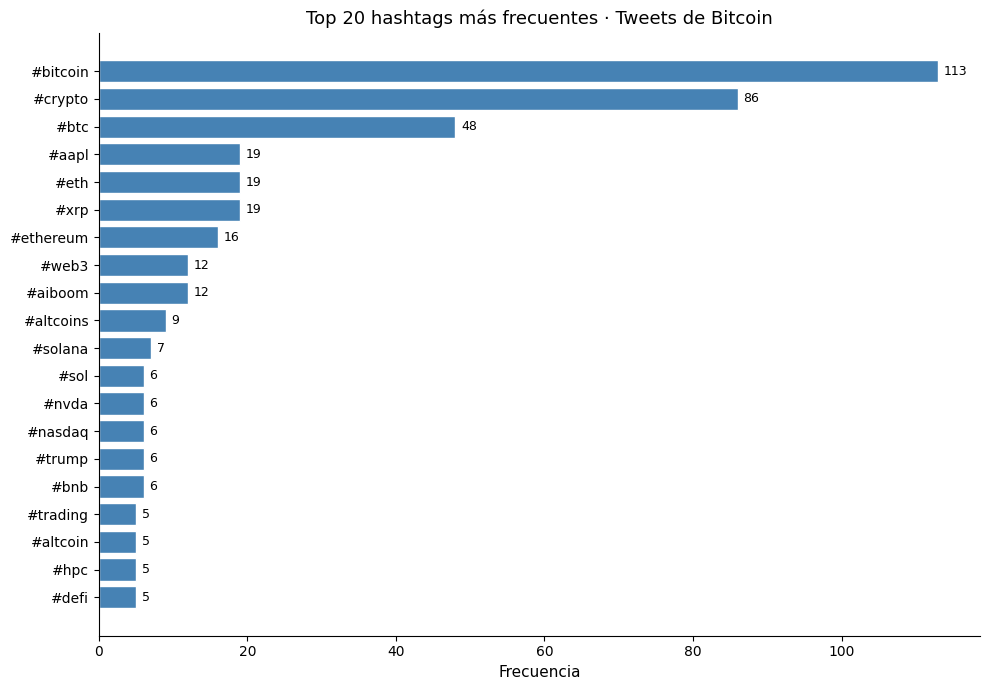

In [10]:
top20 = overall.head(20).sort('frequency')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['hashtag'].to_list(), top20['frequency'].to_list(),
               color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Top 20 hashtags más frecuentes · Tweets de Bitcoin', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Evolución temporal de los top 5 hashtags

Aquí podriamos ver si hubo picos concretos, que probablemente coincidan con alguna noticia importante sobre Bitcoin (sobre adopción, regulaciones, etc.).

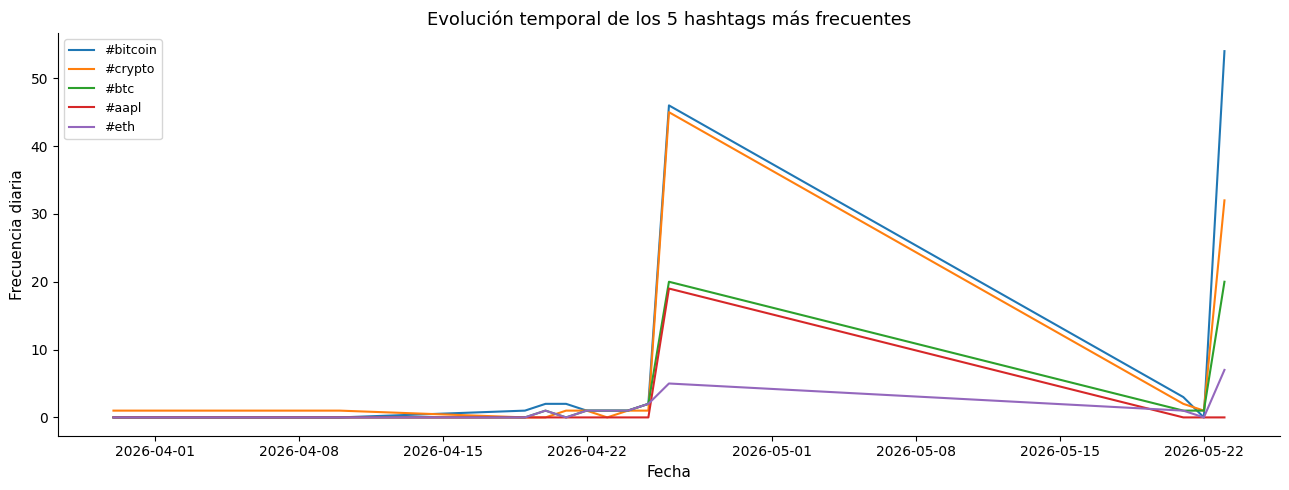

In [11]:
top5_tags = overall.head(5)['hashtag'].to_list()

by_date_top5 = by_date.filter(pl.col('hashtag').is_in(top5_tags))

pivot = (
    by_date_top5
    .pivot(index='date', on='hashtag', values='frequency', aggregate_function='sum')
    .fill_null(0)
    .sort('date')
)

dates = pivot['date'].to_list()

fig, ax = plt.subplots(figsize=(13, 5))
for tag in top5_tags:
    if tag in pivot.columns:
        ax.plot(dates, pivot[tag].to_list(), label=tag, linewidth=1.5)

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Frecuencia diaria', fontsize=11)
ax.set_title('Evolución temporal de los 5 hashtags más frecuentes', fontsize=13)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


En este ejercicio no tenemos una visibilidad real de la evolución de la frecuencia, puesto que todos los que vienen de la llamada a la api son de los días cercanos a la entrega de las prácttocas.

Sería interesante ver como podriamos acercarnos más al dato real pero es dificil debido a las limitaciones de la api.

### ¿Hay bots?

El enunciado pregunta si los hashtags podrían venir casi todos de unos pocos perfiles. Para verlo miro qué usuarios acumulan más usos de hashtags en total. Si unos pocos concentran un porcentaje muy alto, podría ser actividad automatizada, que en Twitter con criptomonedas sería bastante habitual.

In [12]:
# Sumo los hashtags por usuario para ver concentración
user_totals = (
    by_user
    .filter(pl.col('user_name').is_not_null())
    .group_by('user_name')
    .agg(pl.col('frequency').sum().alias('total_hashtag_uses'))
    .sort('total_hashtag_uses', descending=True)
)

total_uses = user_totals['total_hashtag_uses'].sum()
top20_users = user_totals.head(20)
top20_pct = top20_users['total_hashtag_uses'].sum() / total_uses * 100

print(f"Total usos de hashtag en el dataset: {total_uses:,}")
print(f"Top 20 usuarios concentran el {top20_pct:.1f}% del total")
print()
display(top20_users)

Total usos de hashtag en el dataset: 921
Top 20 usuarios concentran el 27.3% del total



user_name,total_hashtag_uses
str,u32
"""PiyasaNabizi""",21
"""Share_Talk""",20
"""iAmFAMZo""",17
"""TaurusInvestTV""",16
"""ChrisCa76642661""",16
…,…
"""Joestuart82""",8
"""CryptoNowNever""",8
"""pete_rizzo_""",8


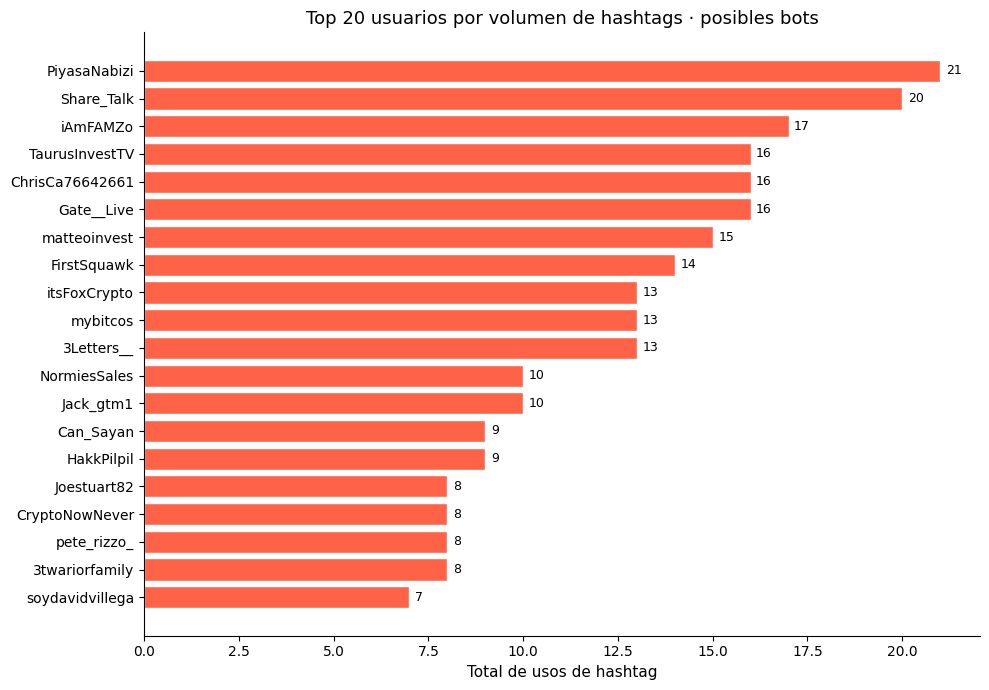

In [13]:
top20_plot = top20_users.sort('total_hashtag_uses')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_plot['user_name'].to_list(),
    top20_plot['total_hashtag_uses'].to_list(),
    color='tomato', edgecolor='white',
)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Total de usos de hashtag', fontsize=11)
ax.set_title('Top 20 usuarios por volumen de hashtags · posibles bots', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Palabras clave

Más allá de los hashtags, extraigo las palabras más frecuentes del texto limpio filtrando stopwords. Esto permite ver qué conceptos y términos aparecen con más fuerza independientemente del uso de `#`.

In [14]:
keywords_df = extractor.analytics_keywords(top_n=30)

# Persistir en gold
keywords_df.write_csv('data/gold/keywords_top.csv')

print(f"Top 30 palabras clave más frecuentes:")
display(keywords_df)

Top 30 palabras clave más frecuentes:


keyword,frequency
str,u32
"""eth""",332
"""market""",230
"""real""",178
"""people""",167
"""money""",138
…,…
"""already""",78
"""liquidity""",78
"""trade""",78


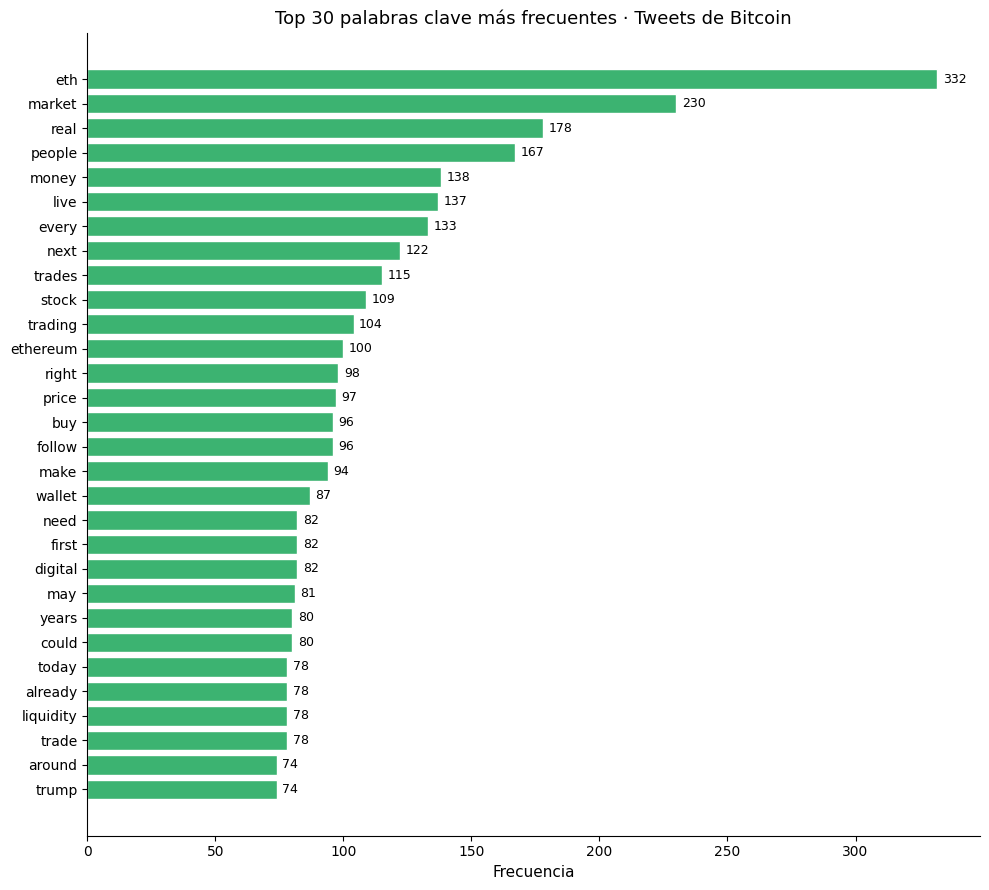

In [15]:
top30_kw = keywords_df.sort('frequency')

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top30_kw['keyword'].to_list(), top30_kw['frequency'].to_list(),
               color='mediumseagreen', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Top 30 palabras clave más frecuentes · Tweets de Bitcoin', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Wordcloud

El tamaño de cada palabra es proporcional a su frecuencia, así que de un vistazo se ve qué hashtags dominan la conversación.

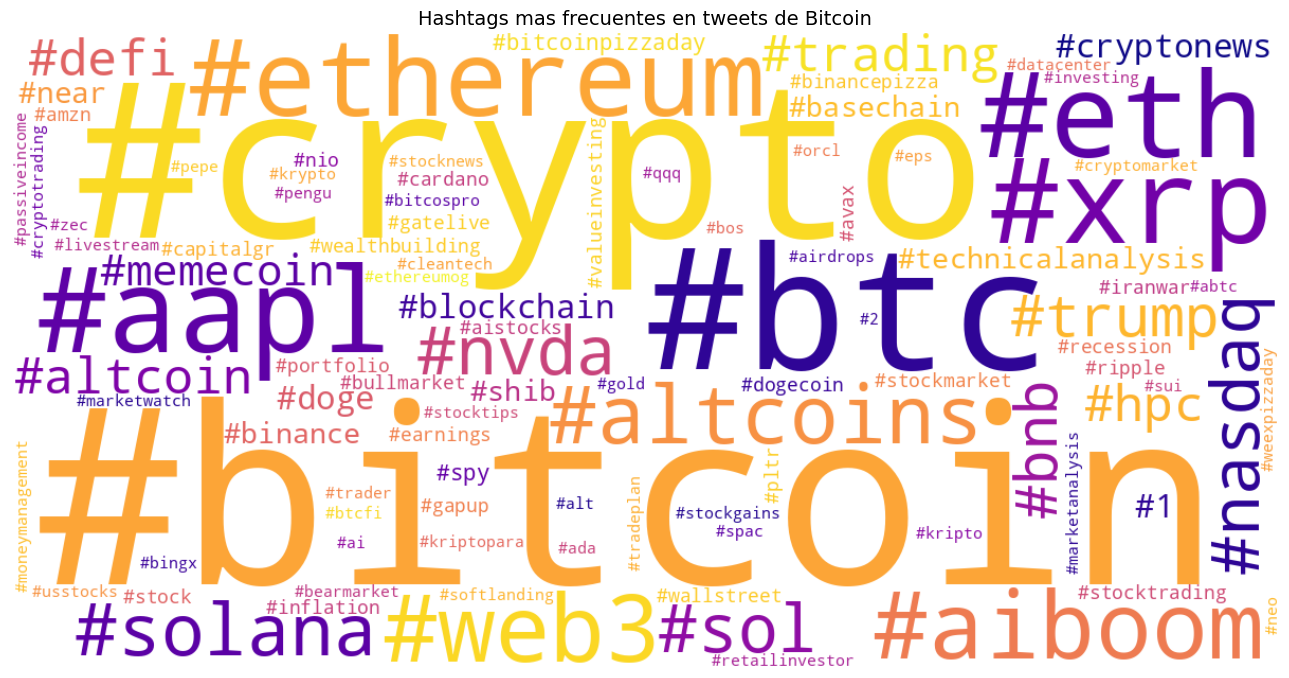

In [16]:
extractor.generate_hashtag_wordcloud(overall_df=overall, max_words=100, figsize=(13, 7))


## 7. Modelado de tópicos con LDA

LDA (Latent Dirichlet Allocation) agrupa los documentos en tópicos a partir de qué palabras aparecen juntas. Cada tópico acaba siendo una distribución de probabilidad sobre el vocabulario.

Comparado con un primer intento que hice, he añadido tres cosas:

1. Filtrar stopwords antes de entrenar. Sin ese paso los tópicos dominantes salían con palabras como "the, to, is, a, of", que no aportan nada. Quito las stopwords inglesas de NLTK más un set extra de Twitter (rt, amp, lol...).
2. Detección de bigramas con `gensim.Phrases`, así expresiones tipo `bull_run` o `all_time_high` cuentan como un solo token.
3. Coherencia c_v como métrica para medir si los tópicos tienen sentido. Por encima de 0.5 ya es razonable.

In [17]:
# Ajusto el sample al tamaño del dataset si tengo menos de 30k tweets
n_total = len(extractor.data)
sample_lda = min(30000, n_total)

lda_result = extractor.model_topics(num_topics=5, passes=10, sample_size=sample_lda,
                                    use_bigrams=True, compute_coherence=True)
topics = lda_result['topics']
coherence = lda_result['coherence']

print(f"Tópicos extraídos por LDA (muestra de {sample_lda:,} tweets):\n")
for i, words in enumerate(topics):
    print(f"  Tópico {i + 1}: {', '.join(words)}")

if coherence is not None:
    print(f"\nCoherencia c_v: {coherence:.4f}")
    if coherence > 0.6:
        calidad = "buena"
    elif coherence > 0.45:
        calidad = "razonable"
    else:
        calidad = "baja, habría que probar otro número de tópicos o limpiar más"
    print(f"Calidad del modelo: {calidad}")

print("\nTópicos guardados en data/gold/topics_lda.json")

Tópicos extraídos por LDA (muestra de 1,632 tweets):

  Tópico 1: eth, crypto, real, people, ethereum, wallet, every, bitcoin, quantum, actually
  Tópico 2: btc, bitcoin, crypto, market, eth, next, money, #bitcoin, xrp, cycle
  Tópico 3: crypto, bitcoin, die, people, eth, market, und, live_trades, btc, stock_crypto
  Tópico 4: bitcoin, crypto, buy, follow_live, stock_crypto, strategies, btc, trades, need, trade
  Tópico 5: btc, #bitcoin, bir, bitcoin, #btc, que, follow, active, timeline, abd

Coherencia c_v: 0.3620
Calidad del modelo: baja, habría que probar otro número de tópicos o limpiar más

Tópicos guardados en data/gold/topics_lda.json


## 8. Análisis de sentimiento

Para cada tweet calculo:
- **Polaridad**: de -1 (muy negativo) a +1 (muy positivo)
- **Subjetividad**: de 0 (objetivo) a 1 (subjetivo)

Pruebo con dos algoritmos distintos:

- **TextBlob**: léxico genérico. Da las dos métricas de un tirón pero le cuestan los emojis y la jerga.
- **VADER**: pensado para redes sociales. Maneja bien emojis, intensificadores (`very`, `super`...) y negaciones. Le paso el texto original (sin limpiar) para que aproveche los emojis.

Para las gráficas posteriores uso TextBlob; VADER lo dejo solo para comparar las dos distribuciones.

In [18]:
# Ajusto el sample al tamaño del dataset
sentiment_sample = min(30000, len(extractor.data))

df_sentiment = extractor.analyze_sentiment(method='textblob', sample_size=sentiment_sample)

print(f"Columnas añadidas: sentiment_polarity, sentiment_subjectivity")
print(f"Tamaño muestra:     {len(df_sentiment):,}")
print(f"Polaridad media:    {df_sentiment['sentiment_polarity'].mean():.3f}")
print(f"Subjetividad media: {df_sentiment['sentiment_subjectivity'].mean():.3f}")
print("\nGuardado en data/gold/sentiment_scored_textblob.parquet")
df_sentiment[['text', 'sentiment_polarity', 'sentiment_subjectivity']].head(5)

Columnas añadidas: sentiment_polarity, sentiment_subjectivity
Tamaño muestra:     1,632
Polaridad media:    0.097
Subjetividad media: 0.343

Guardado en data/gold/sentiment_scored_textblob.parquet


text,sentiment_polarity,sentiment_subjectivity
str,f64,f64
"""🚨 BREAKING TRUMP INSIDER WITH…",0.3,0.55
"""🇺🇸President Trump said that he…",0.55,0.75
"""🇺🇸 PRESIDENT TRUMP DECLARED: “…",0.22,0.377778
"""Bitcoin is not crypto Bitcoin…",0.10021,0.436625
"""▫️ Jan 2014: Janet Yellen beca…",-0.025,0.25


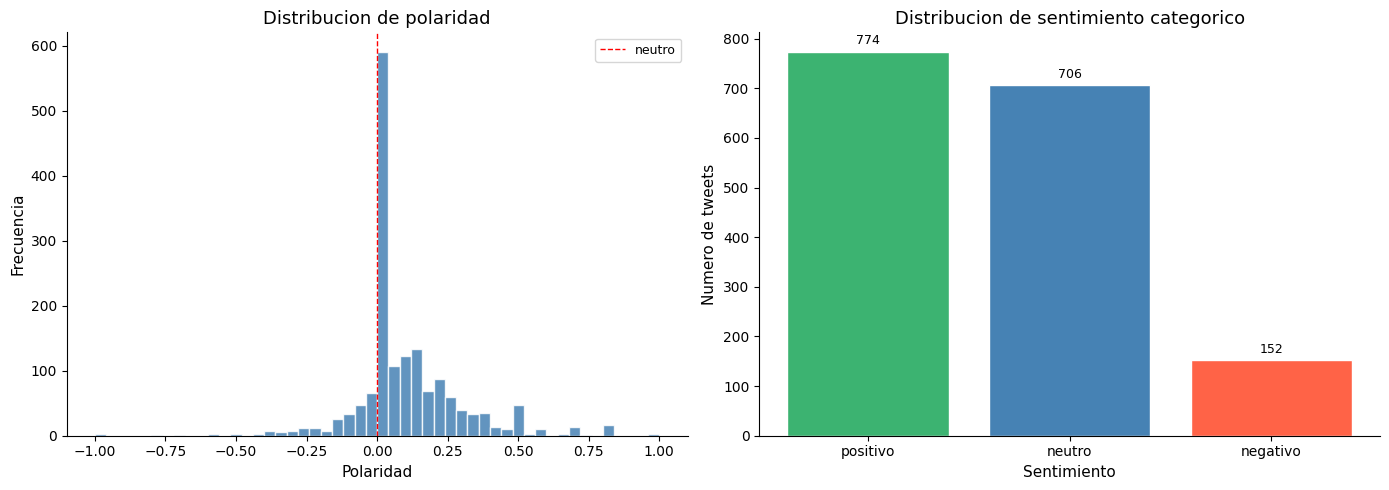

  positivo  :     774  (47.4%)
  neutro    :     706  (43.3%)
  negativo  :     152  (9.3%)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sentiment['sentiment_polarity'].to_numpy(), bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='neutro')
axes[0].set_xlabel('Polaridad', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de polaridad', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

def categorize(p):
    if p > 0.05:
        return 'positivo'
    elif p < -0.05:
        return 'negativo'
    return 'neutro'

cats_df  = df_sentiment.with_columns(
    pl.col('sentiment_polarity').map_elements(categorize, return_dtype=pl.String).alias('category')
)['category'].value_counts()
cat_dict = dict(zip(cats_df['category'].to_list(), cats_df['count'].to_list()))

bar_cats   = ['positivo', 'neutro', 'negativo']
bar_counts = [cat_dict.get(c, 0) for c in bar_cats]
colors_bar = {'positivo': 'mediumseagreen', 'neutro': 'steelblue', 'negativo': 'tomato'}
bar_colors = [colors_bar[c] for c in bar_cats]

axes[1].bar(bar_cats, bar_counts, color=bar_colors, edgecolor='white')
for i, v in enumerate(bar_counts):
    axes[1].text(i, v + max(bar_counts) * 0.02, f'{v:,}', ha='center', fontsize=9)
axes[1].set_xlabel('Sentimiento', fontsize=11)
axes[1].set_ylabel('Numero de tweets', fontsize=11)
axes[1].set_title('Distribucion de sentimiento categorico', fontsize=13)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

total = len(df_sentiment)
for cat in bar_cats:
    n = cat_dict.get(cat, 0)
    print(f'  {cat:<10}: {n:>7,}  ({n/total*100:.1f}%)')


In [20]:
text_col = 'clean_text' if 'clean_text' in df_sentiment.columns else 'text'

idx_max = df_sentiment['sentiment_polarity'].arg_max()
idx_min = df_sentiment['sentiment_polarity'].arg_min()
idx_neu = df_sentiment['sentiment_polarity'].abs().arg_min()

print('Tweet mas POSITIVO (polaridad = {:.2f}):'.format(df_sentiment['sentiment_polarity'][idx_max]))
print(' ', df_sentiment[text_col][idx_max][:200])
print()
print('Tweet mas NEGATIVO (polaridad = {:.2f}):'.format(df_sentiment['sentiment_polarity'][idx_min]))
print(' ', df_sentiment[text_col][idx_min][:200])
print()
print('Tweet mas NEUTRO (polaridad = {:.4f}):'.format(df_sentiment['sentiment_polarity'][idx_neu]))
print(' ', df_sentiment[text_col][idx_neu][:200])


Tweet mas POSITIVO (polaridad = 1.00):
  which #crypto project has the best community ranking time

Tweet mas NEGATIVO (polaridad = -1.00):
  insane president donald trump is reportedly considering to punish spain italy and the united kingdom over their stance during the us iran war a leaked pentagon memo even floated the idea of suspending

Tweet mas NEUTRO (polaridad = 0.0000):
  jk rowling is a savage


### Comparativa TextBlob vs VADER

Ejecuto también VADER sobre la misma muestra y comparo las dos distribuciones de polaridad. Interesa ver si divergen: si VADER marca bastante más sentimiento (positivo o negativo), es señal de que TextBlob está subestimando — un comportamiento típico cuando hay muchos emojis y jerga.

TextBlob - polaridad media: +0.097   std: 0.197
VADER    - polaridad media: +0.182   std: 0.501


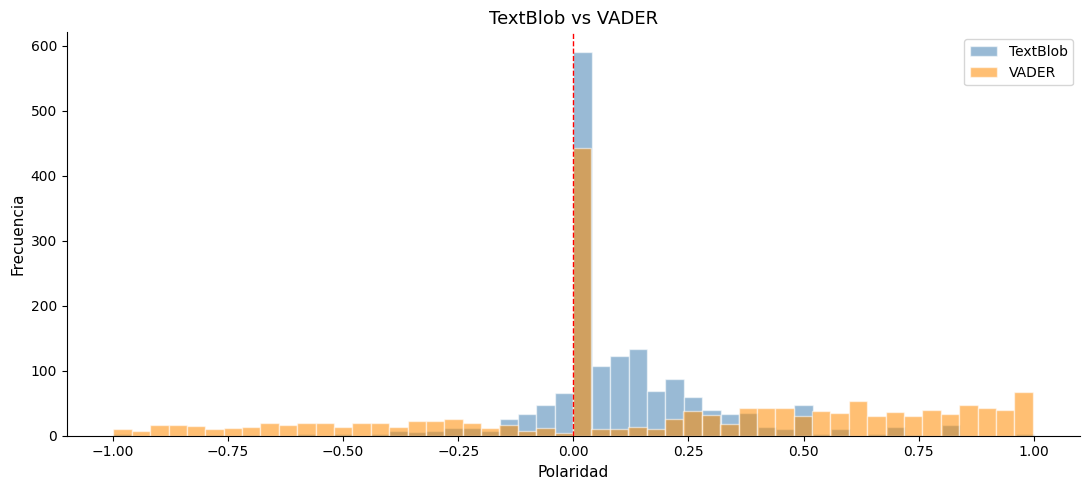

In [21]:
tb_polarity = df_sentiment['sentiment_polarity']  # pl.Series — no hace falta .copy()

df_vader       = extractor.analyze_sentiment(method='vader', sample_size=sentiment_sample)
vader_polarity = df_vader['sentiment_polarity']

print(f'TextBlob - polaridad media: {tb_polarity.mean():+.3f}   std: {tb_polarity.std():.3f}')
print(f'VADER    - polaridad media: {vader_polarity.mean():+.3f}   std: {vader_polarity.std():.3f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(tb_polarity.to_numpy(), bins=50, alpha=0.55, label='TextBlob', color='steelblue', edgecolor='white')
ax.hist(vader_polarity.to_numpy(), bins=50, alpha=0.55, label='VADER', color='darkorange', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Polaridad', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('TextBlob vs VADER', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Restauro TextBlob para las graficas siguientes
df_sentiment = df_sentiment.with_columns(tb_polarity.alias('sentiment_polarity'))
extractor.data = df_sentiment


Aunque los resultados difieren un poco, la tendencia general sí que se mantiene.

### Evolución temporal del sentimiento

Agrupando por día se ve si el sentimiento medio fluctúa dentro de la semana que cubre el dataset. Picos positivos o negativos suelen coincidir con movimientos bruscos del precio o noticias relevantes.

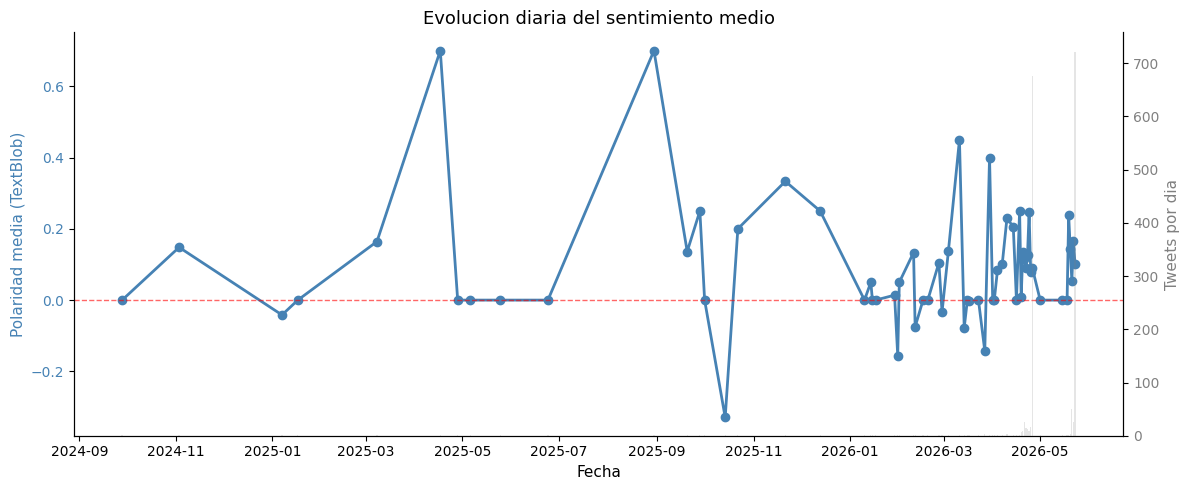

day,mean_polarity,n_tweets
date,f64,u32
2024-09-28,0.0,1
2024-11-03,0.148148,1
2025-01-07,-0.041667,1
2025-01-17,0.0,1
2025-03-08,0.164286,1
…,…,…
2026-05-19,0.2375,2
2026-05-20,0.144444,3
2026-05-21,0.053592,50


In [22]:
daily = (
    df_sentiment
    .with_columns(
        pl.col('date').cast(pl.String)
        .str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
        .dt.date()
        .alias('day')
    )
    .drop_nulls(subset=['day'])
    .group_by('day')
    .agg([
        pl.col('sentiment_polarity').mean().alias('mean_polarity'),
        pl.col('sentiment_polarity').len().alias('n_tweets'),
    ])
    .sort('day')
)

days       = daily['day'].to_list()
polarities = daily['mean_polarity'].to_list()
n_tweets   = daily['n_tweets'].to_list()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(days, polarities, marker='o', color='steelblue', linewidth=2, label='polaridad media')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Polaridad media (TextBlob)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.spines[['top']].set_visible(False)

ax2 = ax1.twinx()
ax2.bar(days, n_tweets, alpha=0.2, color='gray', label='n tweets')
ax2.set_ylabel('Tweets por dia', fontsize=11, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.spines[['top']].set_visible(False)

plt.title('Evolucion diaria del sentimiento medio', fontsize=13)
plt.tight_layout()
plt.show()

display(daily)


Pasa algo parecido a lo que mencionábamos con anterioridad, como la mayoría de registros son muy cercanos a los últimos días, no tenemos una idea real de como evoluciona la polaridad media y solo nos podemos hacer una idea. A priori parece que se van concentrando ligeramente por encima del punto neutro. 

### Sentimiento por hashtag

Cruzando los top 15 hashtags con la polaridad de los tweets que los contienen aparece qué conversaciones son más positivas o más negativas. Un hashtag con sentimiento medio muy distinto a la media general suele señalar un tema con una carga emocional específica.

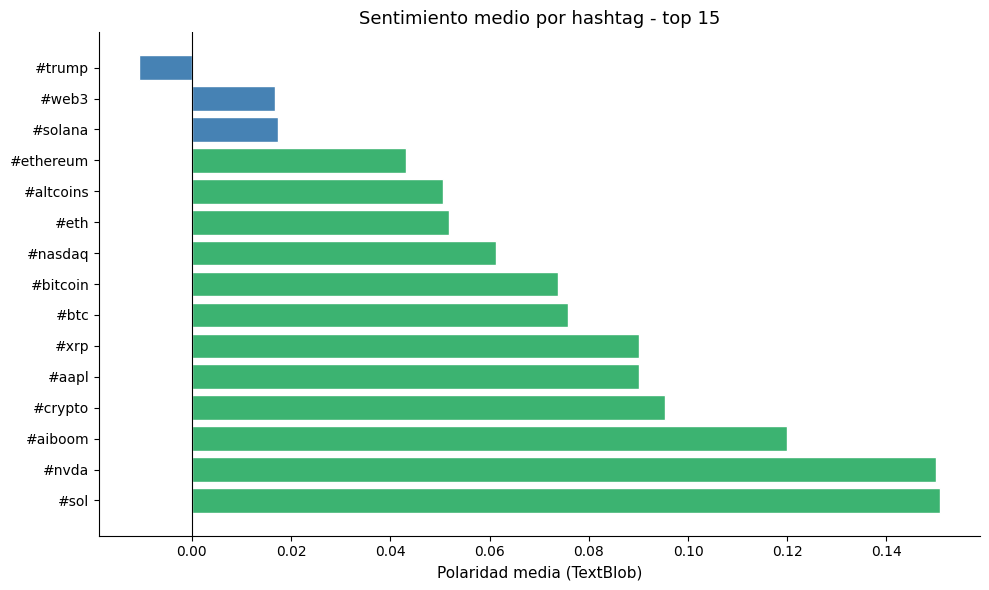

hashtags_found,mean_polarity,n_tweets
str,f64,u32
"""#sol""",0.150777,6
"""#nvda""",0.150025,6
"""#aiboom""",0.119922,12
"""#crypto""",0.095385,86
"""#aapl""",0.090218,19
…,…,…
"""#altcoins""",0.050694,9
"""#ethereum""",0.04318,16
"""#solana""",0.017432,7


In [23]:
top15_tags = overall.head(15)['hashtag'].to_list()

df_hs = df_sentiment.with_columns(
    pl.col('text').fill_null('').map_elements(
        lambda t: [h.lower() for h in extractor.extract_hashtags(t)],
        return_dtype=pl.List(pl.String)
    ).alias('hashtags_found')
)

hashtag_sent = (
    df_hs.select(['sentiment_polarity', 'hashtags_found'])
    .explode('hashtags_found')
    .drop_nulls()
    .filter(pl.col('hashtags_found').is_in(top15_tags))
    .group_by('hashtags_found')
    .agg([
        pl.col('sentiment_polarity').mean().alias('mean_polarity'),
        pl.col('sentiment_polarity').len().alias('n_tweets'),
    ])
    .sort('mean_polarity', descending=True)
)

hashtag_sent.write_csv('data/gold/sentiment_by_hashtag.csv')

tags       = hashtag_sent['hashtags_found'].to_list()
polarities = hashtag_sent['mean_polarity'].to_list()
colors_hs  = ['mediumseagreen' if p > 0.03 else ('tomato' if p < -0.03 else 'steelblue')
               for p in polarities]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tags, polarities, color=colors_hs, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Polaridad media (TextBlob)', fontsize=11)
ax.set_title('Sentimiento medio por hashtag - top 15', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(hashtag_sent)


## 9. Resumen extractivo

`parse_and_summarize()` saca un resumen del corpus puntuando cada oración por la suma de frecuencias de sus palabras (sin contar stopwords) y se queda con las que más puntúan, manteniendo el orden original.

Es un método clásico, sin redes neuronales, pero funciona bastante bien para identificar las oraciones más representativas.

In [24]:
summary_ratio = 0.01  # me quedo con el 1% de las oraciones

resumen = extractor.parse_and_summarize(summary_ratio=summary_ratio)

text_col_s    = 'clean_text' if 'clean_text' in extractor.data.columns else 'text'
corpus_text_s = ' '.join(extractor.data[text_col_s].drop_nulls().cast(pl.String).to_list())
total_sentences = len(nltk.sent_tokenize(corpus_text_s))
seleccionadas   = max(1, int(total_sentences * summary_ratio))

print(f'Oraciones totales en el corpus: {total_sentences:,}')
print(f'Oraciones seleccionadas ({summary_ratio*100:.0f}%): {seleccionadas:,}')
print('\nResumen guardado en data/gold/summary.txt\n')
print('Primeros 2000 caracteres del resumen:')
print(resumen[:2000])


Oraciones totales en el corpus: 1
Oraciones seleccionadas (1%): 1

Resumen guardado en data/gold/summary.txt

Primeros 2000 caracteres del resumen:
breaking trump insider with 100 win rate just opened a 28 000 000 00 oil long ahead of the u s market open this guy just went all in after 12 successful trades in a row and 93 million in profit he definitely knows oil prices will skyrocket on monday president trump said that he has an obligation to ensure the cryptocurrency sector stays in good shape he said that crypto and bitcoin are a huge sector and we should be number one in this sector president trump declared i will stand with the 50 million americans who own crypto and defend their rights i m committed to making sure the next era of bitcoin and digital assets is built in the united states america is on track to become the global hub for crypto bitcoin is not crypto bitcoin is worth 1 56t the total crypto market cap is 2 6t bitcoin is 60 of the total crypto market cap the top 7 crypt

## 10. Parsing sintáctico con spaCy

Hasta ahora el parsing ha sido a nivel de oración (con `nltk.sent_tokenize`) y de
palabra (tokenización + stopwords). Para cumplir el requisito de la rúbrica sobre
"ejemplos de árboles sintácticos", aplico un parsing dependencial con spaCy sobre
un par de tweets de muestra y visualizo el árbol con `displacy`.

El árbol muestra cómo se relacionan sintácticamente las palabras de la oración:
qué palabra es el verbo principal, cuáles son sus sujetos y objetos, qué
adjetivos modifican a qué sustantivos, etc. En textos cortos como tweets ayuda a
ver la estructura más allá del análisis estadístico.

In [25]:
import spacy
from spacy import displacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('Descargando modelo en_core_web_sm de spaCy...')
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

# Limpio los tweets con el metodo de la clase (polars) y cojo dos legibles
df_para_parsing = extractor.data.with_columns(
    pl.col('text').map_elements(extractor.clean_text, return_dtype=pl.String).alias('clean_text')
)
muestra = (
    df_para_parsing
    .filter(pl.col('clean_text').is_not_null())
    .filter(pl.col('clean_text').str.len_chars().is_between(40, 120))
    .head(2)
)

for row in muestra.iter_rows(named=True):
    texto = row['clean_text']
    print(f'--- Tweet ---\n{texto}\n')
    doc = nlp(texto)
    print(f'{"TOKEN":<15} {"POS":<8} {"DEP":<12} HEAD')
    for token in doc:
        print(f'{token.text:<15} {token.pos_:<8} {token.dep_:<12} {token.head.text}')
    print()


--- Tweet ---
today s work office bitcoin and the rest of the market looking great can t complain good morning

TOKEN           POS      DEP          HEAD
today           NOUN     poss         bitcoin
s               PART     case         today
work            NOUN     compound     office
office          NOUN     compound     bitcoin
bitcoin         NOUN     nsubj        complain
and             CCONJ    cc           bitcoin
the             DET      det          rest
rest            NOUN     conj         bitcoin
of              ADP      prep         rest
the             DET      det          market
market          NOUN     pobj         of
looking         VERB     acl          bitcoin
great           ADJ      acomp        looking
can             AUX      aux          complain
t               X        nsubj        complain
complain        VERB     ROOT         complain
good            ADJ      amod         morning
morning         NOUN     npadvmod     complain

--- Tweet ---
it s going t

In [26]:
# Renderizo el arbol del primer tweet con displacy
primer_tweet = muestra['clean_text'][0]
doc = nlp(primer_tweet)

svg = displacy.render(doc, style='dep', jupyter=False, options={'compact': True, 'distance': 90})
Path('data/gold').mkdir(parents=True, exist_ok=True)
Path('data/gold/syntactic_tree.svg').write_text(svg, encoding='utf-8')
print(f'Arbol guardado en data/gold/syntactic_tree.svg')

displacy.render(doc, style='dep', jupyter=True, options={'compact': True, 'distance': 90})


Arbol guardado en data/gold/syntactic_tree.svg


## 11. Análisis de redes con NetworkX

Construyo un grafo dirigido de menciones: cada arista va de un autor al usuario al que menciona, con un peso igual al número de veces que lo menciona. Sobre ese grafo calculo la centralidad de grado (qué cuentas son más mencionadas o influyentes) y la intermediación (cuáles hacen de puente entre grupos), y detecto comunidades con Louvain para ver cómo se agrupan las conversaciones. De aquí salen los insights (top de usuarios por centralidad y hashtag más frecuente) que después alimentan al LLM.

Nodos: 806 | Aristas: 622
Comunidades detectadas (Louvain): 195
Top 3 usuarios por centralidad de grado:
  @natashaajade1: centralidad=0.070, intermediación=0.000, grado=56
  @playboycrypt0: centralidad=0.053, intermediación=0.000, grado=43
  @chistesdelengua: centralidad=0.032, intermediación=0.000, grado=26


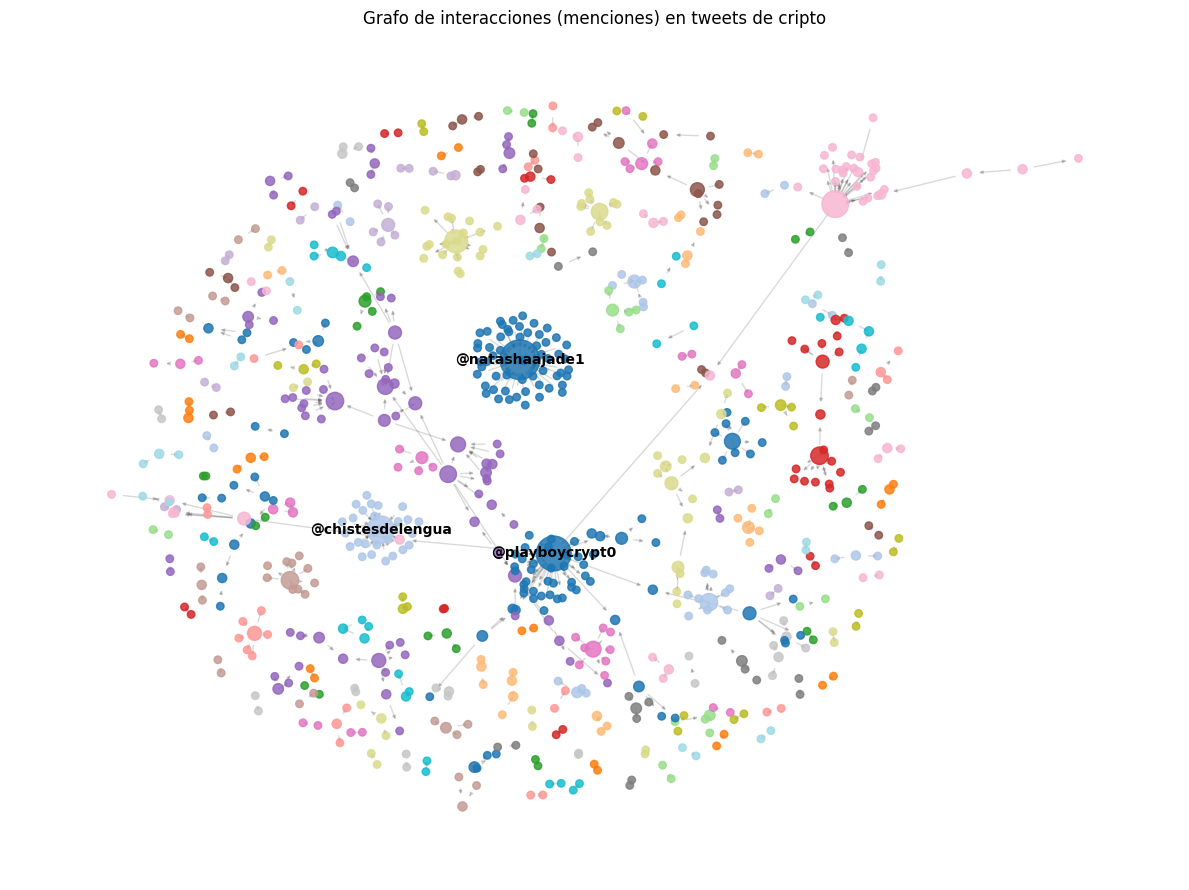

In [27]:
G = extractor.build_interaction_graph()
metricas_red = extractor.analyze_network(G, top_n=3)

## 12. Generación del prompt e integración con el LLM

En lugar de pasarle al modelo los tweets en bruto, le doy un resumen estructurado de la red: usuarios más centrales, número de comunidades, tamaño del grafo y hashtag dominante. Con `generate_prompt_from_network` construyo ese prompt y se lo paso a un modelo Gemma ejecutado en local (`google/gemma-4-E2B-it` por defecto; configurable en `.env`), que devuelve una interpretación en lenguaje natural de las tendencias observadas en la red.

In [30]:
prompt_red = extractor.generate_prompt_from_network(G)
print(prompt_red)

Nodos: 806 | Aristas: 622
Comunidades detectadas (Louvain): 195
Top 3 usuarios por centralidad de grado:
  @natashaajade1: centralidad=0.070, intermediación=0.000, grado=56
  @playboycrypt0: centralidad=0.053, intermediación=0.000, grado=43
  @chistesdelengua: centralidad=0.032, intermediación=0.000, grado=26
Eres un analista de redes sociales. A partir de estos datos de una red de menciones en tweets sobre criptomonedas, explica posibles razones de las tendencias observadas.

- Usuarios más influyentes (por centralidad): @natashaajade1, @playboycrypt0, @chistesdelengua
- Hashtag más frecuente: #bitcoin
- Comunidades detectadas: 195
- Tamaño de la red: 806 usuarios y 622 interacciones.

Responde en español de forma concisa y directa, en 2-3 párrafos como máximo; no te extiendas más de lo necesario.


In [31]:
# Levanta Gemma en local (la primera vez descarga ~5 GB). Necesita HF_TOKEN en .env.
respuesta = extractor.chat_local_llm(prompt=prompt_red)
print(respuesta)

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Como analista de redes sociales, los datos sugieren una dinámica de conversación centrada en Bitcoin. La alta centralidad de usuarios como @natashaajade1, @playboycrypt0 y @chistesdelengua indica que estos perfiles son nodos clave que impulsan la visibilidad y el flujo de información dentro de esta red. Esto sugiere que la conversación está siendo moldeada por voces influyentes y que su contenido tiene un gran impacto en la difusión de temas relacionados con criptomonedas.

El hashtag predominante, #bitcoin, confirma que este activo es el tema central de la discusión. Aunque el tamaño de la red es moderado (806 usuarios), la cantidad de interacciones (622) en relación con el número de usuarios sugiere una comunidad activa y enfocada. La existencia de 195 comunidades detectadas indica que el tema no está concentrado en un solo grupo, sino que se está dispersando en múltiples nichos o subtemas dentro del ecosistema de Bitcoin.


Para el chat interactivo en una app, ejecuta `python scripts/app_gradio.py` (interfaz Gradio con el chat y el grafo de la red).

## Conclusiones

Algunas cosas que saco después del análisis:

El grafo de menciones sale muy fragmentado: muchas comunidades pequeñas y la centralidad concentrada en unas pocas cuentas con intermediación casi nula. Tiene sentido, porque en los tweets "Top" se ven mensajes sueltos con poca conversación entre usuarios, así que apenas hay cadenas de menciones que conecten a unos con otros. Pasar esos insights a Gemma en local funciona como capa interpretativa: el modelo contextualiza las métricas en lenguaje natural. Al ser un modelo pequeño, conviene tomar su análisis como apoyo y no como conclusión definitiva.